In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("data/king_barchart.csv", index_col=[0])
df

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
Bar-headed Goose,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001500,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Emperor Goose,0.001500,0.001500,0.000166,0.000000,0.001500,0.000000,0.000000,0.000000,0.000000,0.000094,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Snow Goose,0.008840,0.011015,0.009874,0.006409,0.004843,0.003702,0.003044,0.002053,0.002888,0.004787,...,0.030268,0.033454,0.016299,0.024885,0.02043,0.014618,0.009499,0.013473,0.012375,0.009437
Ross's Goose,0.006306,0.001419,0.000083,0.000259,0.000161,0.001500,0.000000,0.001500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Graylag Goose,0.000177,0.000167,0.000083,0.000259,0.000323,0.000073,0.000056,0.000000,0.000241,0.000282,...,0.000255,0.000000,0.000000,0.000118,0.00000,0.000090,0.000107,0.000378,0.000120,0.000069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Black-headed Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000181,0.000000,0.000118,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Blue Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Lazuli Bunting,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Indigo Bunting,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00012,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
# Filter out less common birds
df = df[(df.max(axis=1) > 0.01)].copy()
df

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
Snow Goose,0.008840,0.011015,0.009874,0.006409,0.004843,0.003702,0.003044,0.002053,0.002888,0.004787,...,0.030268,0.033454,0.016299,0.024885,0.020430,0.014618,0.009499,0.013473,0.012375,0.009437
Greater White-fronted Goose,0.017032,0.013685,0.011616,0.011328,0.007749,0.006388,0.005862,0.010171,0.008664,0.008261,...,0.026309,0.018767,0.013269,0.015804,0.017065,0.017936,0.011527,0.010703,0.013817,0.013184
Brant,0.016561,0.016188,0.020826,0.016960,0.016790,0.014808,0.013021,0.025380,0.023827,0.025814,...,0.000639,0.002992,0.004284,0.009081,0.012258,0.012734,0.015370,0.012591,0.012375,0.015612
Cackling Goose,0.070486,0.063084,0.060239,0.065186,0.043187,0.035424,0.028183,0.041056,0.030084,0.043274,...,0.085568,0.087398,0.065301,0.079844,0.075472,0.076944,0.054969,0.067867,0.070287,0.059256
Canada Goose,0.202204,0.224299,0.237720,0.254337,0.219971,0.212906,0.201680,0.282542,0.269073,0.306393,...,0.249936,0.250771,0.204263,0.235051,0.244442,0.239530,0.180382,0.205742,0.209299,0.204899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Townsend's Warbler,0.028171,0.031041,0.029954,0.028806,0.027607,0.042175,0.043684,0.027153,0.020858,0.024312,...,0.027969,0.029465,0.028419,0.032905,0.031246,0.033988,0.029566,0.036767,0.037847,0.040106
Wilson's Warbler,0.000295,0.000167,0.000000,0.000130,0.000000,0.000000,0.001500,0.000000,0.000000,0.000000,...,0.000766,0.000363,0.000731,0.000944,0.001562,0.001345,0.000747,0.000504,0.000360,0.000139
Western Tanager,0.000412,0.000167,0.000332,0.000324,0.001500,0.000218,0.000169,0.000093,0.000401,0.000094,...,0.001149,0.000816,0.001776,0.001415,0.000721,0.000538,0.000427,0.000504,0.000841,0.000694
Black-headed Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000181,0.000000,0.000118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
df.loc[:, "min"] = df.min(axis=1)
df.loc[:, "max"] = df.max(axis=1)
df.loc[:, "min"] = df["min"].replace(0, 0.001)
df.loc[:, "ratio"] = df["max"] / df["min"]
df

,1,2,3,4,5,6,7,8,9,10,...,42,43,44,45,46,47,48,min,max,ratio
Snow Goose,0.008840,0.011015,0.009874,0.006409,0.004843,0.003702,0.003044,0.002053,0.002888,0.004787,...,0.024885,0.020430,0.014618,0.009499,0.013473,0.012375,0.009437,0.001000,0.033454,33.454200
Greater White-fronted Goose,0.017032,0.013685,0.011616,0.011328,0.007749,0.006388,0.005862,0.010171,0.008664,0.008261,...,0.015804,0.017065,0.017936,0.011527,0.010703,0.013817,0.013184,0.001000,0.032306,32.305600
Brant,0.016561,0.016188,0.020826,0.016960,0.016790,0.014808,0.013021,0.025380,0.023827,0.025814,...,0.009081,0.012258,0.012734,0.015370,0.012591,0.012375,0.015612,0.001000,0.033887,33.887000
Cackling Goose,0.070486,0.063084,0.060239,0.065186,0.043187,0.035424,0.028183,0.041056,0.030084,0.043274,...,0.079844,0.075472,0.076944,0.054969,0.067867,0.070287,0.059256,0.001000,0.087398,87.398000
Canada Goose,0.202204,0.224299,0.237720,0.254337,0.219971,0.212906,0.201680,0.282542,0.269073,0.306393,...,0.235051,0.244442,0.239530,0.180382,0.205742,0.209299,0.204899,0.154092,0.332300,2.156500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Townsend's Warbler,0.028171,0.031041,0.029954,0.028806,0.027607,0.042175,0.043684,0.027153,0.020858,0.024312,...,0.032905,0.031246,0.033988,0.029566,0.036767,0.037847,0.040106,0.005632,0.053292,9.462995
Wilson's Warbler,0.000295,0.000167,0.000000,0.000130,0.000000,0.000000,0.001500,0.000000,0.000000,0.000000,...,0.000944,0.001562,0.001345,0.000747,0.000504,0.000360,0.000139,0.001000,0.279569,279.569100
Western Tanager,0.000412,0.000167,0.000332,0.000324,0.001500,0.000218,0.000169,0.000093,0.000401,0.000094,...,0.001415,0.000721,0.000538,0.000427,0.000504,0.000841,0.000694,0.000093,0.145658,1561.182208
Black-headed Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.226001,226.001100


In [5]:
# Find weeks close to the max value
df.loc[:, "max_weeks"] = df.iloc[:, :48].apply(
    lambda row: row[row >= row.max() - 0.01].index.tolist(), axis=1
)
df

,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,min,max,ratio,max_weeks
Snow Goose,0.008840,0.011015,0.009874,0.006409,0.004843,0.003702,0.003044,0.002053,0.002888,0.004787,...,0.020430,0.014618,0.009499,0.013473,0.012375,0.009437,0.001000,0.033454,33.454200,"[39, 40, 42]"
Greater White-fronted Goose,0.017032,0.013685,0.011616,0.011328,0.007749,0.006388,0.005862,0.010171,0.008664,0.008261,...,0.017065,0.017936,0.011527,0.010703,0.013817,0.013184,0.001000,0.032306,32.305600,"[36, 37, 38, 39]"
Brant,0.016561,0.016188,0.020826,0.016960,0.016790,0.014808,0.013021,0.025380,0.023827,0.025814,...,0.012258,0.012734,0.015370,0.012591,0.012375,0.015612,0.001000,0.033887,33.887000,"[8, 10, 11, 12, 13, 14, 15, 16]"
Cackling Goose,0.070486,0.063084,0.060239,0.065186,0.043187,0.035424,0.028183,0.041056,0.030084,0.043274,...,0.075472,0.076944,0.054969,0.067867,0.070287,0.059256,0.001000,0.087398,87.398000,"[38, 39, 40, 42]"
Canada Goose,0.202204,0.224299,0.237720,0.254337,0.219971,0.212906,0.201680,0.282542,0.269073,0.306393,...,0.244442,0.239530,0.180382,0.205742,0.209299,0.204899,0.154092,0.332300,2.156500,"[12, 14, 15]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Townsend's Warbler,0.028171,0.031041,0.029954,0.028806,0.027607,0.042175,0.043684,0.027153,0.020858,0.024312,...,0.031246,0.033988,0.029566,0.036767,0.037847,0.040106,0.005632,0.053292,9.462995,"[7, 17, 18]"
Wilson's Warbler,0.000295,0.000167,0.000000,0.000130,0.000000,0.000000,0.001500,0.000000,0.000000,0.000000,...,0.001562,0.001345,0.000747,0.000504,0.000360,0.000139,0.001000,0.279569,279.569100,[18]
Western Tanager,0.000412,0.000167,0.000332,0.000324,0.001500,0.000218,0.000169,0.000093,0.000401,0.000094,...,0.000721,0.000538,0.000427,0.000504,0.000841,0.000694,0.000093,0.145658,1561.182208,[19]
Black-headed Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,0.226001,226.001100,[20]


In [27]:
def get_birds(col, limit):
    bird_set = set()
    for month in range(1, 13):
        top = list(
            df[
                df["max_weeks"].apply(
                    lambda row: sum(
                        [str(4 * (month - 1) + i) in row for i in [1, 2, 3, 4]]
                    )
                    > 0
                )
            ]
            .sort_values(col, ascending=False)
            .index[:limit]
        )
        bird_set.update(top)
    return list(bird_set)


get_birds("max", 5)

['House Finch',
 'Turkey Vulture',
 'Double-crested Cormorant',
 'Barn Swallow',
 "Bewick's Wren",
 'Song Sparrow',
 "Swainson's Thrush",
 'Dark-eyed Junco',
 'American Goldfinch',
 'Varied Thrush',
 'Rock Pigeon',
 'American Wigeon',
 'Cliff Swallow',
 'Cedar Waxwing',
 'Red-breasted Nuthatch',
 'Gadwall',
 'Golden-crowned Kinglet',
 'Common Merganser',
 'Black-capped Chickadee',
 'European Starling',
 'Green-winged Teal',
 'Fox Sparrow',
 'Northern Flicker',
 'Pied-billed Grebe',
 'Osprey',
 'American Robin',
 'Violet-green Swallow',
 'Common Goldeneye',
 'Ring-necked Duck',
 'Glaucous-winged Gull',
 'American Coot',
 'White-crowned Sparrow',
 "Anna's Hummingbird",
 'Yellow-rumped Warbler',
 'Chestnut-backed Chickadee',
 'House Sparrow',
 "Steller's Jay",
 'Mallard',
 'Pacific Wren',
 'Spotted Towhee',
 'Bufflehead',
 'American Crow',
 'Belted Kingfisher']

In [7]:
df_subset

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
Turkey Vulture,0.000236,0.000167,0.001500,0.000065,0.000161,0.000000,0.000056,0.000653,0.000883,0.002441,...,0.002299,0.000997,0.001045,0.000000,0.000360,0.001500,0.001500,0.000504,0.000120,0.000000
Short-billed Gull,0.117574,0.111482,0.116163,0.114254,0.105505,0.083406,0.064765,0.090884,0.088006,0.082794,...,0.130396,0.145603,0.137185,0.146951,0.133878,0.131289,0.133205,0.129564,0.111258,0.115876
Barn Swallow,0.000766,0.002587,0.003734,0.005179,0.007184,0.005009,0.004284,0.006158,0.005455,0.005914,...,0.001405,0.000725,0.001045,0.001061,0.000360,0.001076,0.000320,0.000755,0.002163,0.000555
Wilson's Snipe,0.020863,0.020277,0.022984,0.024663,0.016952,0.018510,0.012626,0.020995,0.019013,0.019619,...,0.043934,0.041342,0.030300,0.032787,0.038457,0.027262,0.023695,0.022538,0.026553,0.020885
Swainson's Thrush,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000383,0.000091,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Black-headed Grosbeak,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000181,0.000000,0.000118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Tree Swallow,0.000000,0.000000,0.000000,0.000065,0.000161,0.000436,0.002987,0.013716,0.028801,0.055477,...,0.000128,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000069
Lesser Scaup,0.065299,0.072096,0.073681,0.071077,0.060785,0.053789,0.046108,0.070542,0.059366,0.065803,...,0.026692,0.040435,0.035733,0.050832,0.043504,0.048426,0.043761,0.048854,0.062838,0.067374
Common Yellowthroat,0.000354,0.000083,0.000498,0.000518,0.000242,0.000000,0.000113,0.000840,0.000241,0.000000,...,0.005875,0.003173,0.001567,0.001179,0.001442,0.001076,0.000320,0.000378,0.000481,0.000833
Caspian Tern,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000094,...,0.007407,0.000997,0.000105,0.000118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


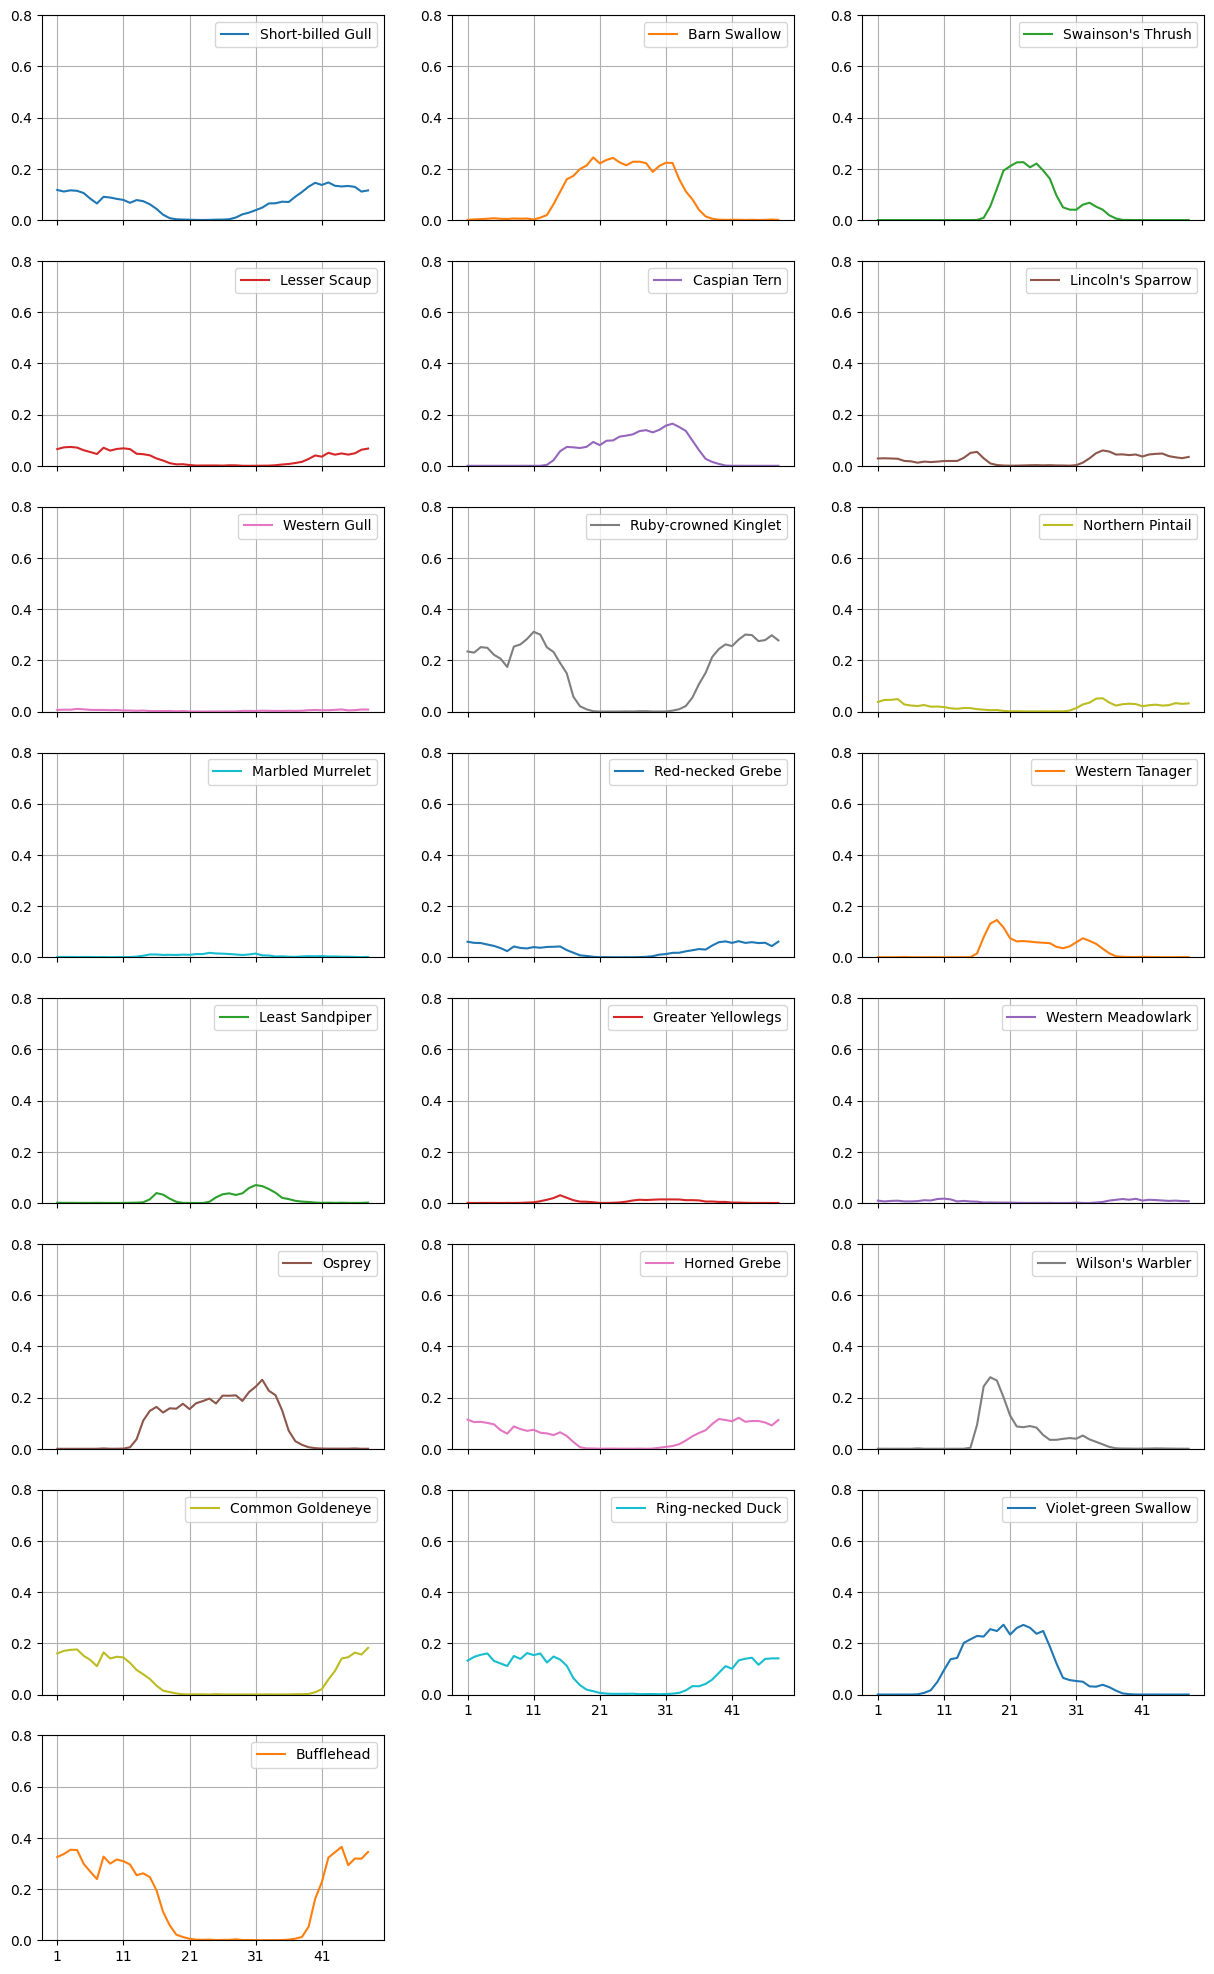

In [26]:
df_subset = df.loc[get_birds("ratio", 3)].iloc[:, :48]
axes = df_subset.T.plot(
    kind="line",
    subplots=True,
    layout=(math.ceil(df_subset.shape[0] / 3), 3),
    figsize=(15, 25),
    ylim=(0, 0.8),
    grid=True,
)

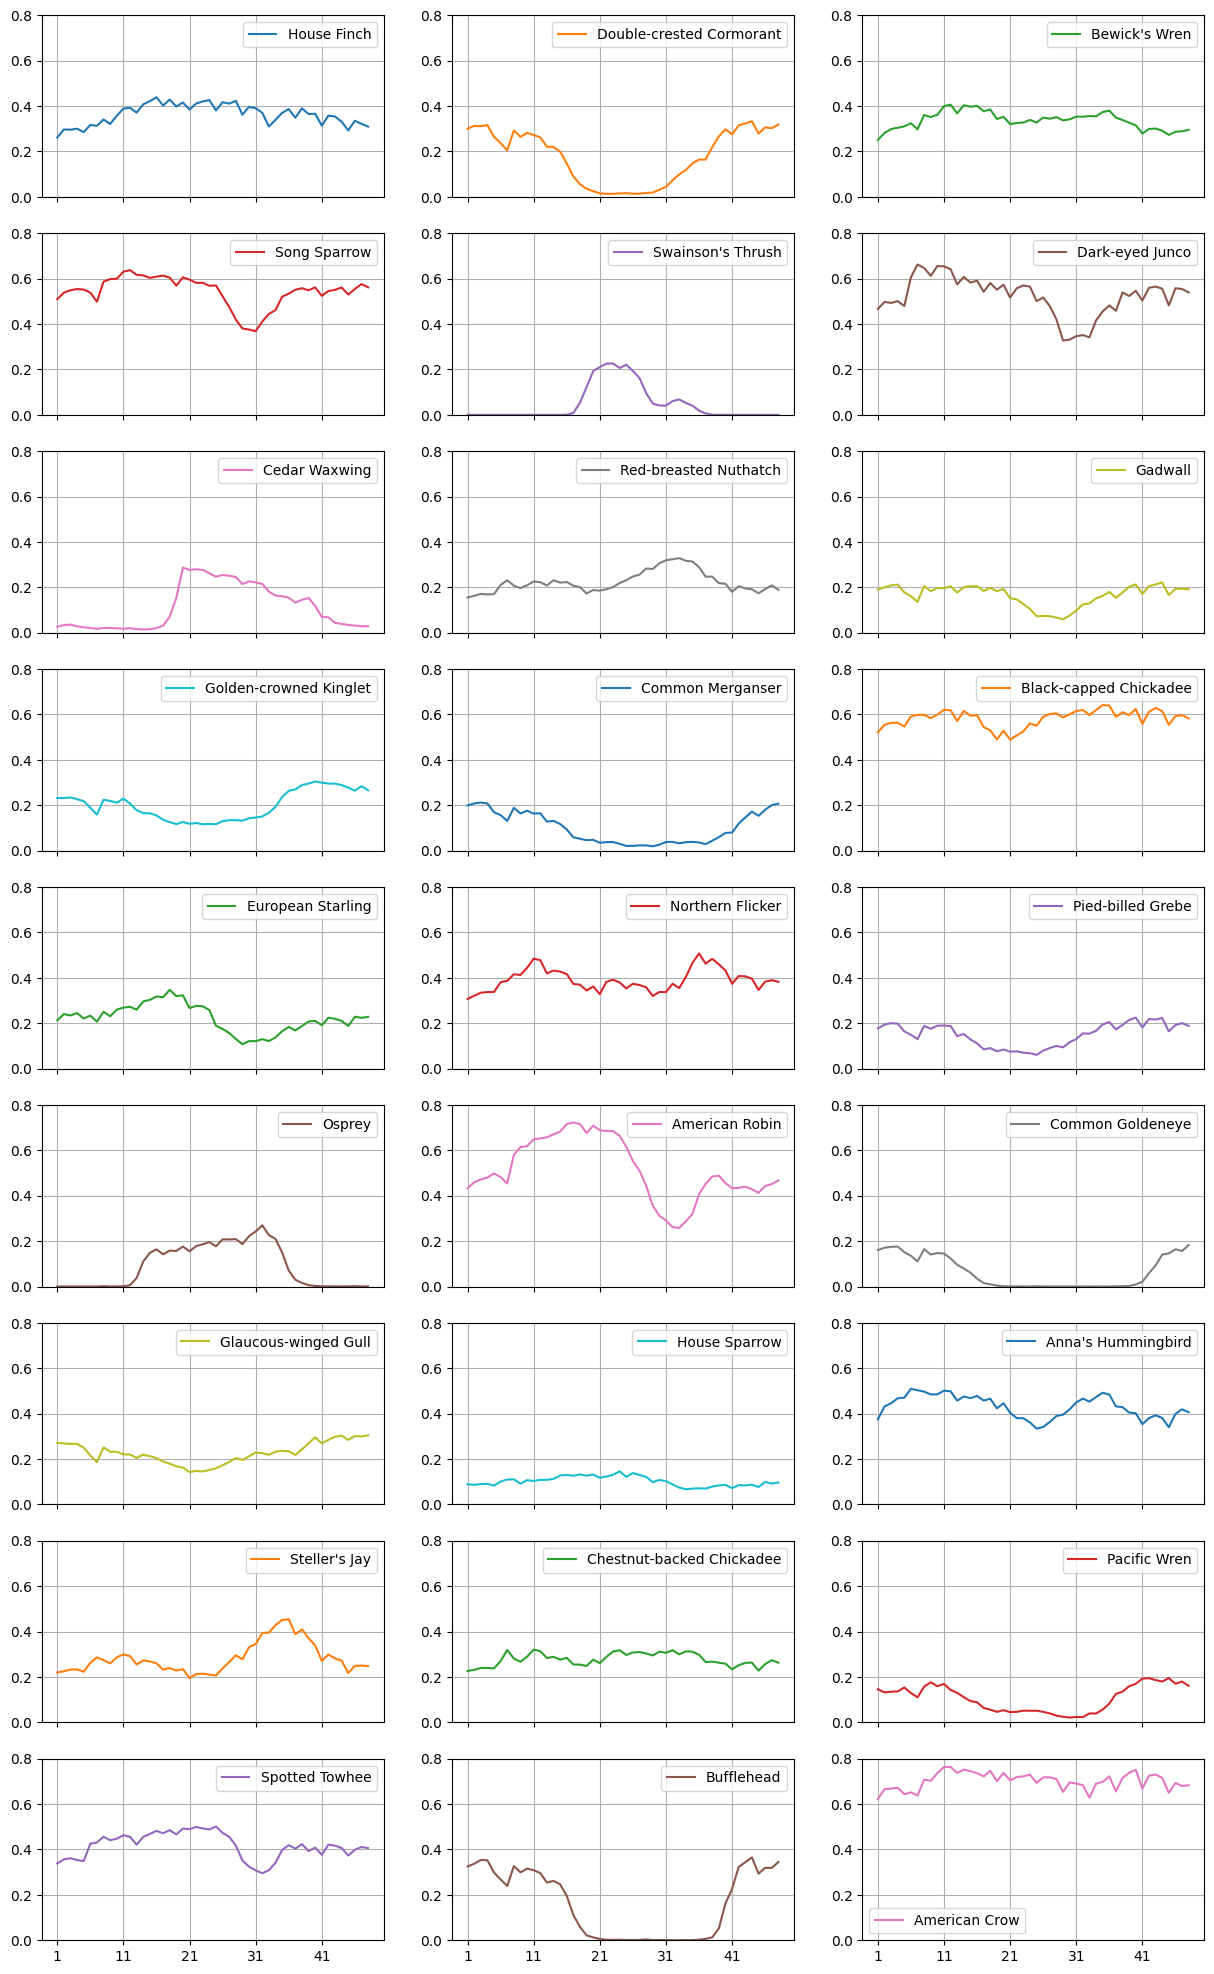

In [24]:
df_subset = df.loc[get_birds("max", 3)].iloc[:, :48]
axes = df_subset.T.plot(
    kind="line",
    subplots=True,
    layout=(math.ceil(df_subset.shape[0] / 3), 3),
    ylim=(0, 0.8),
    figsize=(15, 25),
    grid=True,
)

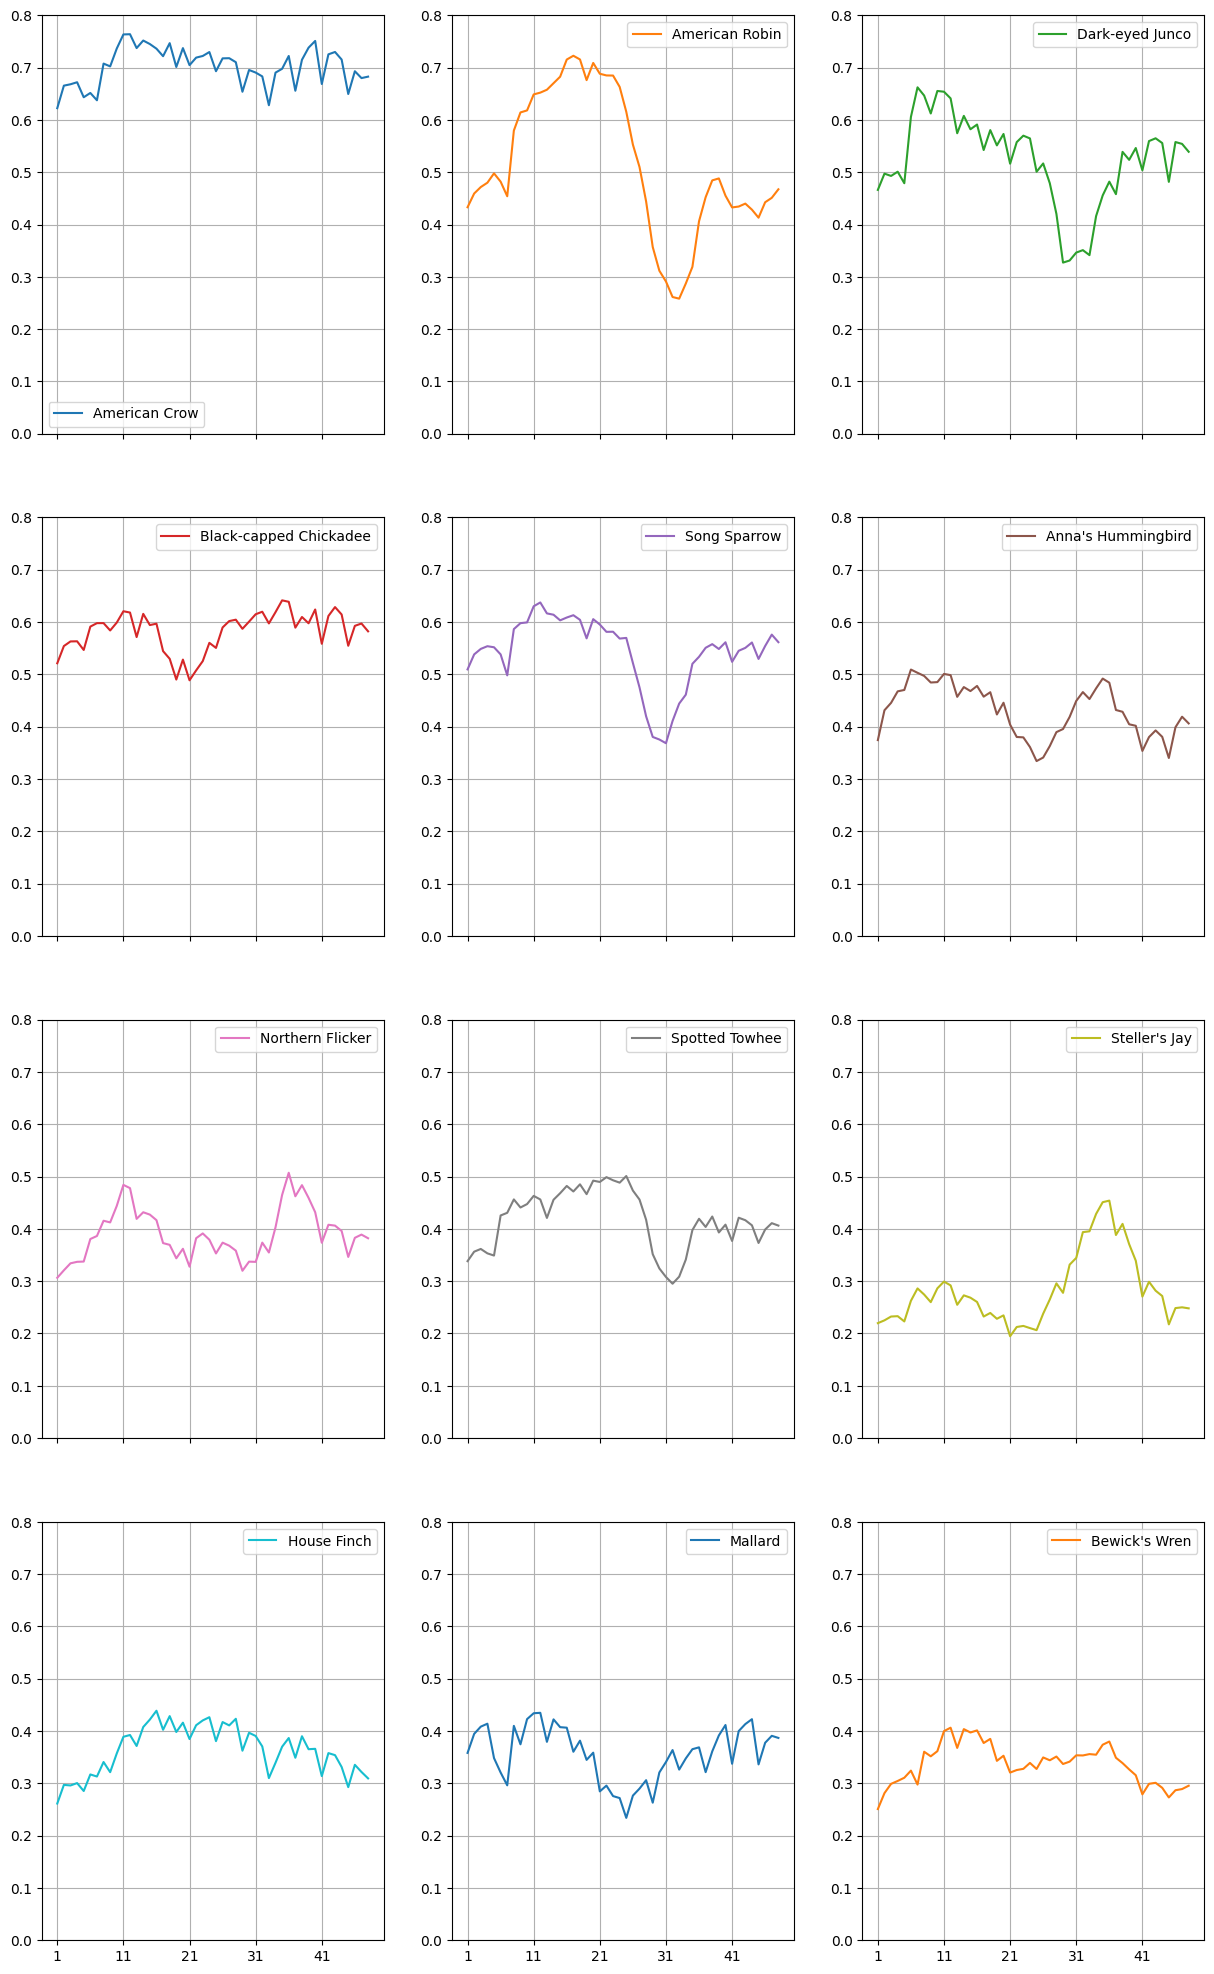

In [29]:
df_subset = df.sort_values("max", ascending=False).iloc[:12, :48]
axes = df_subset.T.plot(
    kind="line",
    subplots=True,
    layout=(math.ceil(df_subset.shape[0] / 3), 3),
    figsize=(15, 25),
    ylim=(0, 0.8),
    grid=True,
)

In [30]:
df_subset.index

Index(['American Crow', 'American Robin', 'Dark-eyed Junco',
       'Black-capped Chickadee', 'Song Sparrow', 'Anna's Hummingbird',
       'Northern Flicker', 'Spotted Towhee', 'Steller's Jay', 'House Finch',
       'Mallard', 'Bewick's Wren'],
      dtype='object')